<!-- Badges: -->

<!-- Title: -->
<div align="center">
  <h1><b> State Measurement </b></h1>
  <h2> Quantum Circuit Theory and Implementations </h2>
</div>
<br>

<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

<div align='center'>
<table class="tfo-notebook-buttons" align="head">
  <td>
    <a target="_blank" href="https://github.com/QuCAI-Lab/quantum-circuit-theory"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" /></a>
  </td>
</table>
</div>

# Table of Contents

- Bell states (Maximally Entangled States)
- Measuring Bell states 
- What is the global state of the system after measuring only one of the qubits?
- What is the connection with the partial trace?
- The 3-qubit GHZ state

# &nbsp; <img valign="middle" height="45px" src="https://img.icons8.com/python" width="45" hspace="0px" vspace="0px"> Importing modules

In [15]:
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit import QuantumCircuit, assemble, Aer, execute, assemble
from qiskit.quantum_info import Statevector

In [16]:
# If you get hit by the error "No module named watermark", run this cell twice!

#%load_ext watermark
%reload_ext watermark
%watermark -a 'LucasCamponogaraViera' -gu 'QuCAI-Lab' -ws 'https://github.com/QuCAI-Lab/quantum-circuit-theory' -w -u -d -v -m -iv

Author: LucasCamponogaraViera

Github username: QuCAI-Lab

Website: https://github.com/QuCAI-Lab/quantum-circuit-theory

Last updated: 2024-10-12

Python implementation: CPython
Python version       : 3.11.2
IPython version      : 8.28.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-45-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

Watermark: 2.3.1



# Bell states

Bell states are a set of four 2-qubit maximally entangled pure states, defined as:

$$|\phi^+ \rangle = \frac{1}{\sqrt(2)}(|00\rangle + |11\rangle).$$
$$|\phi^- \rangle = \frac{1}{\sqrt(2)}(|00\rangle - |11\rangle).$$
$$|\psi^+ \rangle = \frac{1}{\sqrt(2)}(|01\rangle + |10\rangle).$$
$$|\psi^- \rangle = \frac{1}{\sqrt(2)}(|01\rangle - |10\rangle).$$

Each subsystem (1-qubit) of a Bell state, after tracing out (discarding) one of the qubits, is in a maximally mixed reduced state, i.e., a state of maximum entropy, i.e., the least amount of classical knowledge (predictability power) about the state of the system upon measurement. Mixed states should then be represented by a density operator with equal diagonal entries that represent a uniform probability distribution over states $|0\rangle$ and $|1\rangle$.

It is possible to go from one Bell state to another via simple local operations, which do not change the degree of entanglement. For instance:

$$\sigma_x |\phi^+ \rangle = |\psi^+ \rangle.$$

In [17]:
'''State |phi+>'''

#sim = Aer.get_backend('aer_simulator')  # Define the simulator backend.
qc = QuantumCircuit(2)                   # Creates the circuit object.
qc.h(0), qc.cx(0,1)                      # Add gates to the circuit.
#qc.save_statevector()                   # Tell simulator to save the statevector.
#qobj = assemble(qc)                     # Create a Qobj from the circuit for the simulator to run.
#result = sim.run(qobj).result()         # Run the simulation and return the result.
#out_state = result.get_statevector()    #
#print(out_state)                        # Print the resulting state vector.
print(Statevector.from_instruction(qc))
qc.draw() 

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

In [18]:
'''State |phi->'''

qc = QuantumCircuit(2) 
qc.x(0), qc.h(0), qc.cx(0,1) 
print(Statevector.from_instruction(qc))
qc.draw() 

Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))


┌───┐┌───┐     
q_0: ┤ X ├┤ H ├──■──
     └───┘└───┘┌─┴─┐
q_1: ──────────┤ X ├
               └───┘

In [19]:
'''State |psi+>'''

qc = QuantumCircuit(2) 
qc.h(0), qc.x(1), qc.cx(0,1) 
print(Statevector.from_instruction(qc))
qc.draw() 

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘

In [20]:
'''State |psi->'''

qc = QuantumCircuit(2) 
qc.h(0), qc.x(1), qc.z(1), qc.z(0), qc.cx(0,1) 
print(Statevector.from_instruction(qc))
qc.draw() 

Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


┌───┐┌───┐     
q_0: ┤ H ├┤ Z ├──■──
     ├───┤├───┤┌─┴─┐
q_1: ┤ X ├┤ Z ├┤ X ├
     └───┘└───┘└───┘

# Measuring Bell states 

In [12]:
'''State |phi+>'''

qc = QuantumCircuit(2) 
qc.h(0), qc.cx(0,1) 
qc.draw() 

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

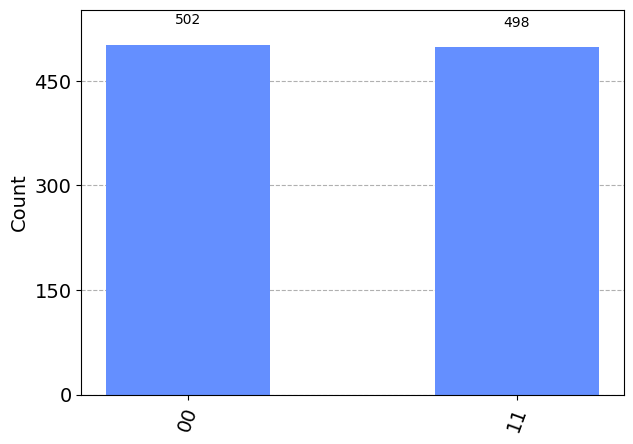

In [13]:
qc.measure_all() # Measure all the qubits.
backend = Aer.get_backend('qasm_simulator') # Backend simulator.
counts = execute(qc, backend, shots = 1000).result().get_counts() # Run the simulation and get counts.
plot_histogram(counts) # Plot a histogram of outcomes and corresponding probabilities.

# What is the global state of the system after measuring only one of the qubits?

# What is the connection with the partial trace?

# The 3-qubit GHZ state

The Greenberger-Horne-Zeilinger (GHZ) state is an entangled state of three qubits defined by:

$$|GHZ \rangle = \frac{1}{\sqrt2}(|000\rangle + |111\rangle).$$

In [7]:
'''GHZ'''

def GHZ():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.cx(0,1), qc.cx(1,2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ()
qc.draw() 

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════

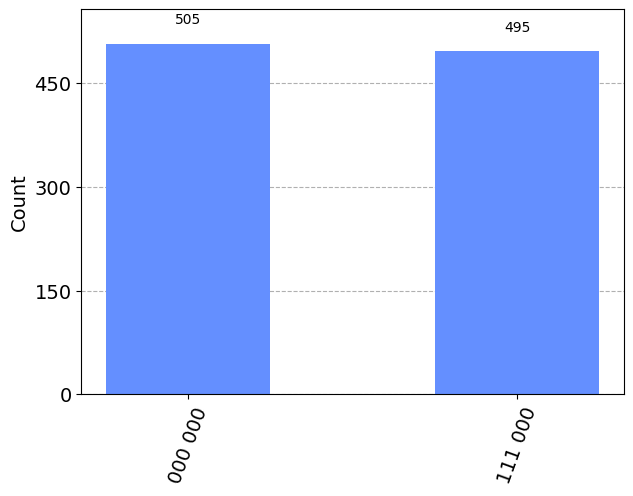

In [8]:
qc.measure_all() # Measure all the qubits.
backend = Aer.get_backend('qasm_simulator') # Backend simulator.
counts = execute(qc, backend, shots = 1000).result().get_counts() # Run the simulation and get counts.
plot_histogram(counts) # Plot a histogram of outcomes and corresponding probabilities.

A GHZ-like state is the following:

$$|\psi \rangle = \frac{1}{\sqrt2}(|011\rangle - |100\rangle).$$

In [9]:
def GHZ_Like():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.x(2), qc.cx(0,1), qc.cx(1,2), qc.z(2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ_Like()
qc.draw() 

Statevector([ 0.        +0.j,  0.        +0.j,  0.        +0.j,
              0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
              0.        +0.j,  0.        +0.j],
            dims=(2, 2, 2))


┌───┐               
q_0: ┤ H ├──■────────────
     └───┘┌─┴─┐          
q_1: ─────┤ X ├──■───────
     ┌───┐└───┘┌─┴─┐┌───┐
q_2: ┤ X ├─────┤ X ├┤ Z ├
     └───┘     └───┘└───┘
c: 3/════════════════════

In [10]:
from qiskit.opflow import One, Zero
import math

ghz_state=(1/math.sqrt(2))*((Zero^One^One)-(One^Zero^Zero))
ghz_state.to_matrix()

array([ 0.        +0.j,  0.        +0.j,  0.        +0.j,  0.70710678+0.j,
       -0.70710678+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j])

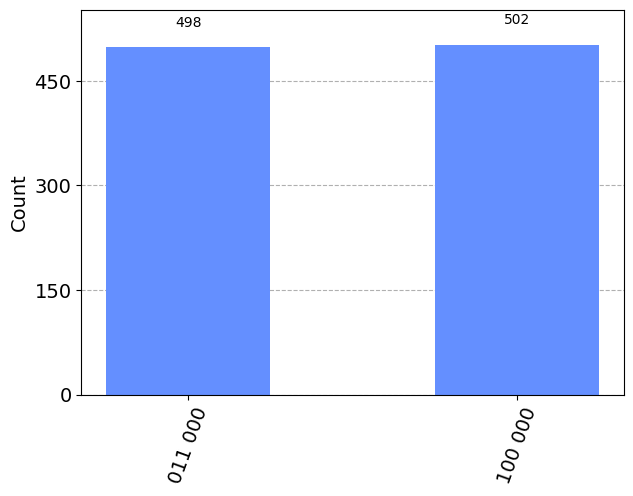

In [11]:
qc.measure_all() # Measure all the qubits.
backend = Aer.get_backend('qasm_simulator') # Backend simulator.
counts = execute(qc, backend, shots = 1000).result().get_counts() # Run the simulation and get counts.
plot_histogram(counts) # Plot a histogram of outcomes and corresponding probabilities.

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

\[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed.<a name="ref1" />  
- Corollary 4.2, pg. 176: Gate decomposition.
- Theorem 4.3, pg. 207: Trotter formula. 
- Chapter 4.7.2, pg. 206: The quantum simulation algorithm. 

\[2] [ibmq-qsim-challenge.ipynb](https://github.com/qiskit-community/open-science-prize-2021/blob/main/ibmq-qsim-challenge.ipynb).

\[3] [ibmq-qsim-sup-mat.ipynb](https://github.com/qiskit-community/open-science-prize-2021/blob/main/ibmq-qsim-sup-mat.ipynb).

\[4] [YQIS 6 Invited 8: Yuan Su, Trotterization and Trotter error](https://www.youtube.com/watch?v=KPofFJc57gU).<a name="ref5" />  

\[5] [Quantum Algorithms for Hamiltonian Simulation | Quantum Colloquium](https://www.youtube.com/watch?v=X4gegxIuh1o).<a name="ref6" />  